In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\fayzul\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fayzul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fayzul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
# Load dataset
df = pd.read_csv('train.csv', header=None)

# Give proper column names
df.columns = ['label', 'title', 'review']

# Quick look at data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (3600000, 3)

First 5 rows:


,label,title,review
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [5]:
# Drop missing values
df.dropna(inplace=True)

# Remove duplicate reviews
df.drop_duplicates(inplace=True)

# Keep only 10000 rows for faster processing
df = df.sample(10000, random_state=42)

# Reset index
df.reset_index(drop=True, inplace=True)

# Clean review text
df['review'] = df['review'].str.lower()           # make lowercase
df['review'] = df['review'].str.replace(r'[^a-zA-Z\s]', '', regex=True)  # remove special chars
df['review'] = df['review'].str.strip()            # remove extra spaces

print("Data Cleaned!")
print("Shape after cleaning:", df.shape)
df.head()

Data Cleaned!
Shape after cleaning: (10000, 3)


,label,title,review
0,1,Wings Over The Pacific,a very poor movie there were no germany squard...
1,1,Disappointed...really disappointed.,i am really disappointed by this oxo turner i ...
2,1,"Yes, great descriptions but a bit labored, no?",im not sorrry i plowed through this book but i...
3,2,Excellent!,excellent book the characterization was superb...
4,2,Retro Cap,perfect retro cap i directed a play wherein on...


In [6]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    score = sia.polarity_scores(str(text))
    return score['compound']  # compound score between -1 and +1

# Function to classify sentiment
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply to dataset
df['sentiment_score'] = df['review'].apply(get_sentiment)
df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

print("Sentiment Analysis Done!")
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

Sentiment Analysis Done!

Sentiment Distribution:
sentiment
Positive    6977
Negative    2633
Neutral      390
Name: count, dtype: int64


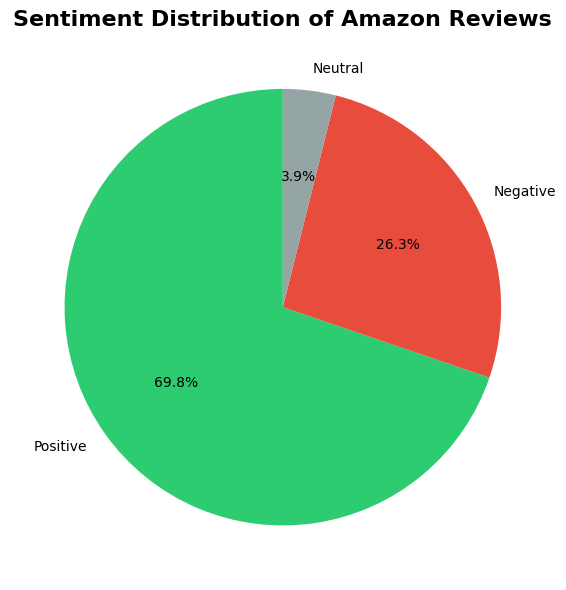

Pie chart saved!


In [7]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c', '#95a5a6']  # green, red, gray
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title('Sentiment Distribution of Amazon Reviews', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pie chart saved!")

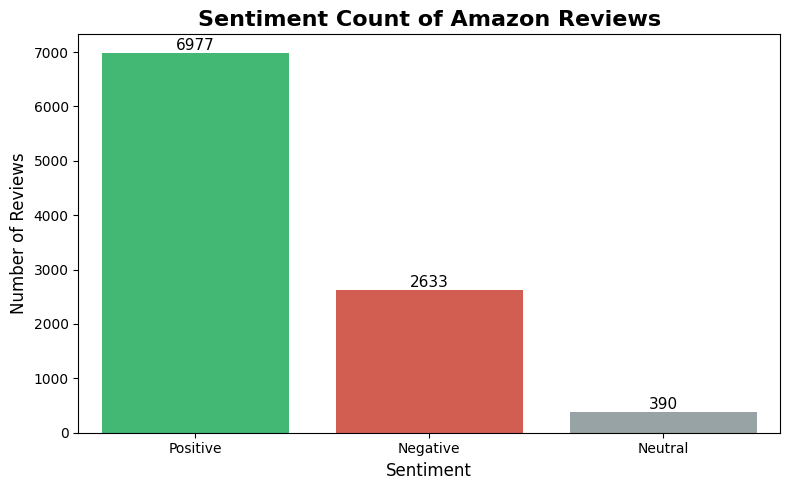

Bar chart saved!


In [8]:
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#95a5a6']

sns.countplot(
    data=df,
    x='sentiment',
    order=['Positive', 'Negative', 'Neutral'],
    palette={'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
)

plt.title('Sentiment Count of Amazon Reviews', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Add count labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

plt.tight_layout()
plt.savefig('sentiment_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved!")

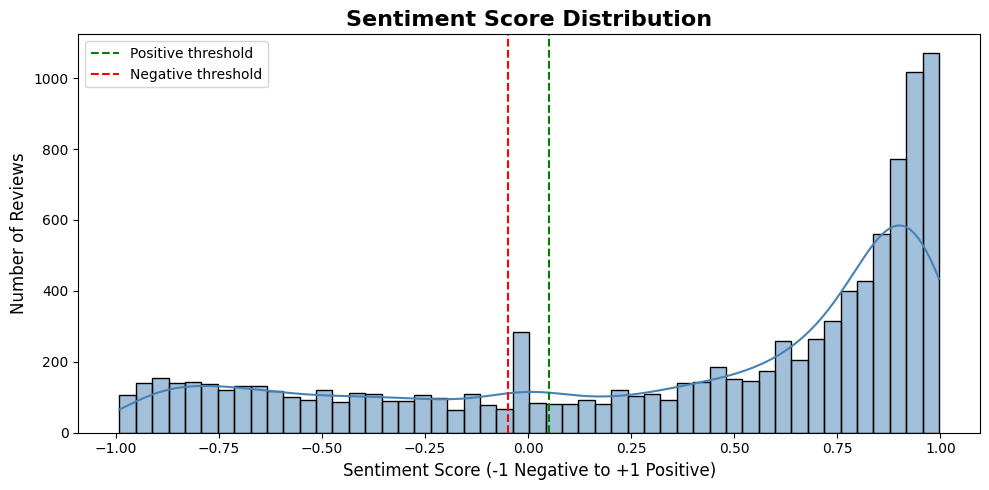

Distribution chart saved!


In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['sentiment_score'],
    bins=50,
    kde=True,
    color='steelblue'
)

plt.title('Sentiment Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment Score (-1 Negative to +1 Positive)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
plt.axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
plt.legend()
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution chart saved!")

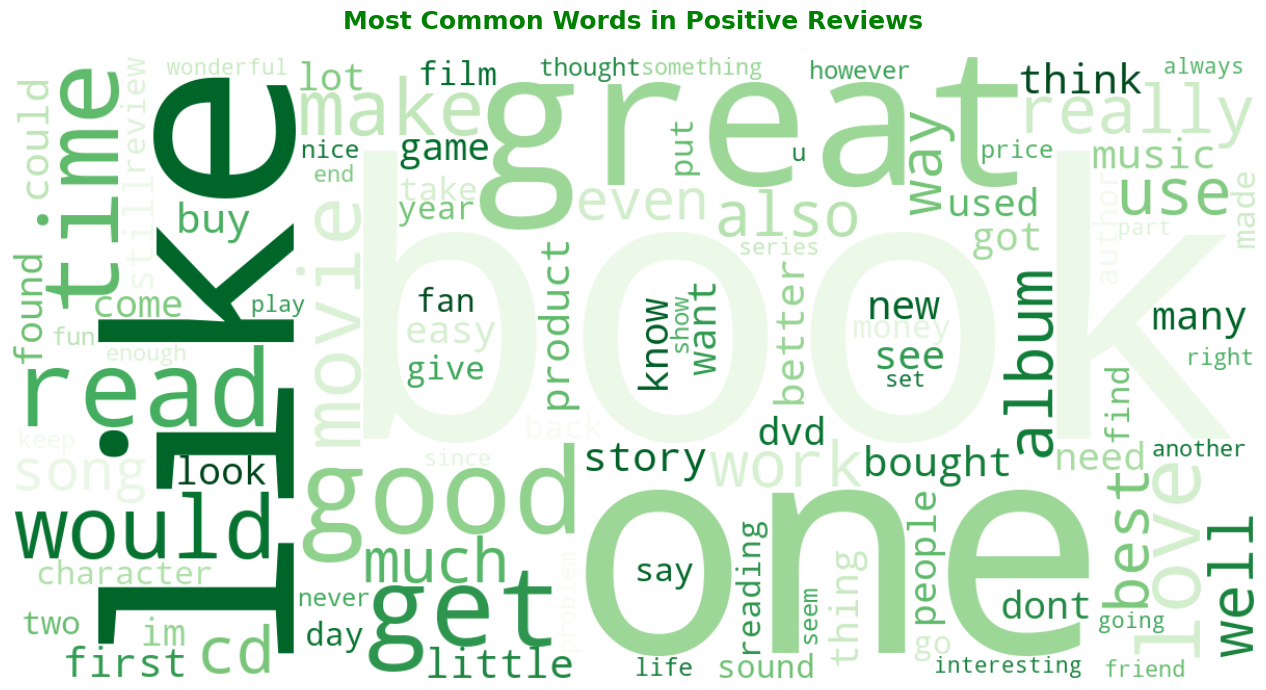

Positive wordcloud saved!


In [10]:
# Get all positive reviews text
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['review'])

# Remove stopwords
stop_words = set(stopwords.words('english'))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Greens',
    stopwords=stop_words,
    max_words=100
).generate(positive_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews',
          fontsize=18, fontweight='bold', color='green', pad=20)
plt.tight_layout()
plt.savefig('positive_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Positive wordcloud saved!")

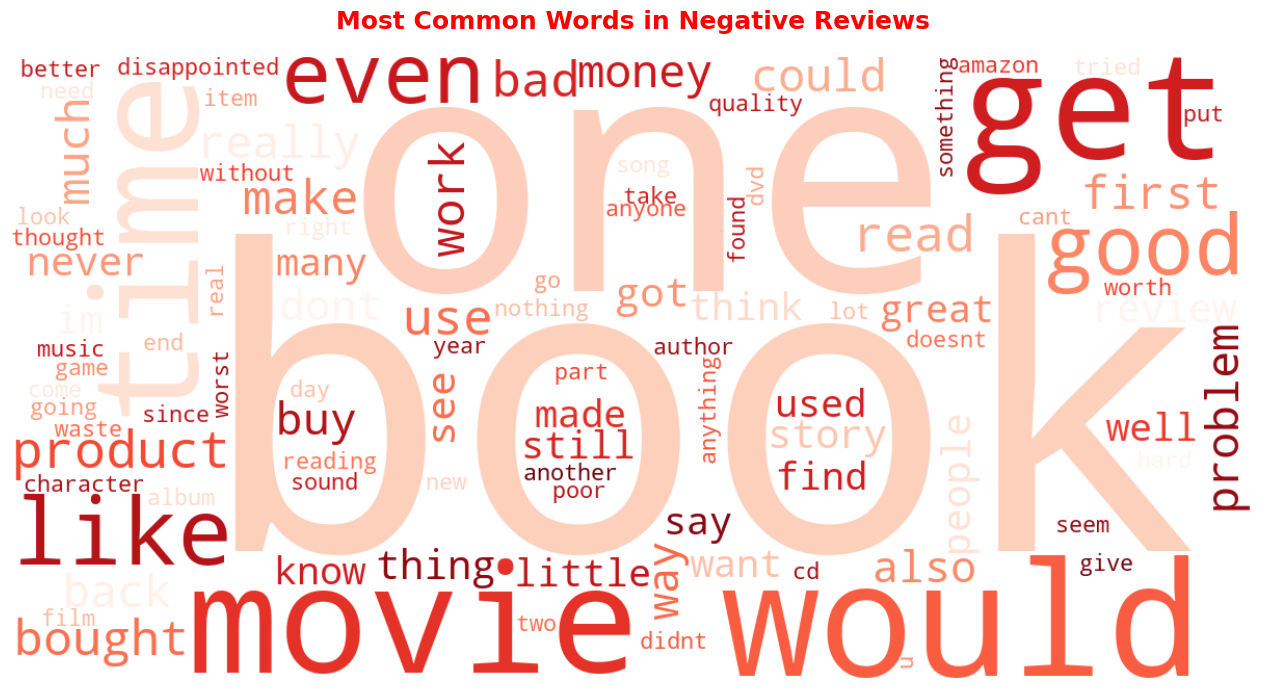

Negative wordcloud saved!


In [11]:
# Get all negative reviews text
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['review'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Reds',
    stopwords=stop_words,
    max_words=100
).generate(negative_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews',
          fontsize=18, fontweight='bold', color='red', pad=20)
plt.tight_layout()
plt.savefig('negative_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Negative wordcloud saved!")

In [12]:
print("=== TOP 5 MOST POSITIVE REVIEWS ===\n")
top_positive = df.nlargest(5, 'sentiment_score')[['review', 'sentiment_score']]
for i, row in top_positive.iterrows():
    print(f"Score: {row['sentiment_score']:.2f}")
    print(f"Review: {row['review'][:150]}...")
    print()

print("\n=== TOP 5 MOST NEGATIVE REVIEWS ===\n")
top_negative = df.nsmallest(5, 'sentiment_score')[['review', 'sentiment_score']]
for i, row in top_negative.iterrows():
    print(f"Score: {row['sentiment_score']:.2f}")
    print(f"Review: {row['review'][:150]}...")
    print()

=== TOP 5 MOST POSITIVE REVIEWS ===

Score: 1.00
Review: this book is a treat for people who like the fantasy world but it is definitely not restricted to that audience it is also a must for anyone who just ...

Score: 1.00
Review: a marriage made in heaven that of wine and desserts what a wonderful idea the bringing together of two of the worlds best offerings wine and dessert i...

Score: 1.00
Review: it was definitely different but deep down i think this was just a good oldfashioned finding yourself flick it was an emotional roller coaster too but ...

Score: 1.00
Review: when ben carson was  years old his father left his house he suffered discrimination for being afroamerican and faced poverty it wasnt an easy life but...

Score: 1.00
Review: its amazing how many people are so hard on the barenaked ladies this fine canadian band consistently puts out fine recordings without making their fan...


=== TOP 5 MOST NEGATIVE REVIEWS ===

Score: -0.99
Review: i cant believe i watched this

In [13]:
# Save analyzed data to CSV
df[['review', 'sentiment_score', 'sentiment']].to_csv(
    'sentiment_results.csv', index=False
)
print("Results saved to sentiment_results.csv!")

Results saved to sentiment_results.csv!


In [14]:
total = len(df)
positive = len(df[df['sentiment'] == 'Positive'])
negative = len(df[df['sentiment'] == 'Negative'])
neutral = len(df[df['sentiment'] == 'Neutral'])

print(f"""
=== SENTIMENT ANALYSIS INSIGHTS ===

Total Reviews Analyzed : {total}
Positive Reviews       : {positive} ({positive/total*100:.1f}%)
Negative Reviews       : {negative} ({negative/total*100:.1f}%)
Neutral Reviews        : {neutral} ({neutral/total*100:.1f}%)

Average Sentiment Score: {df['sentiment_score'].mean():.2f}

Key Findings:
✅ Majority of Amazon reviews are Positive
✅ Negative reviews use words like 'waste', 'bad', 'poor'
✅ Positive reviews use words like 'great', 'love', 'perfect'
✅ Most reviews have strong opinions (few Neutral)
✅ VADER works well for short product reviews
""")


=== SENTIMENT ANALYSIS INSIGHTS ===

Total Reviews Analyzed : 10000
Positive Reviews       : 6977 (69.8%)
Negative Reviews       : 2633 (26.3%)
Neutral Reviews        : 390 (3.9%)

Average Sentiment Score: 0.37

Key Findings:
✅ Majority of Amazon reviews are Positive
✅ Negative reviews use words like 'waste', 'bad', 'poor'
✅ Positive reviews use words like 'great', 'love', 'perfect'
✅ Most reviews have strong opinions (few Neutral)
✅ VADER works well for short product reviews

